In [39]:
import os
import random
import time
import gc

import numpy as np
import pandas as pd
from IPython.display import display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

from datetime import date

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)


DATAPATH = 'external/amn_release/Dataset_model/e_coli_core_UB_15400.npz' 

In [53]:
def set_seed(seed=42):
    """
    Set all random seeds for reproducibility across different devices.
    
    Args:
        seed (int): Random seed value (default: 42)
    """
    # Python random module
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch CPU
    torch.manual_seed(seed)
    
    # PyTorch CUDA (NVIDIA GPUs)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    # PyTorch MPS (Apple Silicon)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    
    
    os.environ['PYTHONHASHSEED'] = str(seed)


def get_device(device_type=None):
    """
    Select device with manual override option
    
    Args:
        device_type: 'cuda', 'mps', 'cpu', or None for auto-selection
    """
    if device_type:
        return torch.device(device_type)
    
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Training on device: {device}")

print(f"PyTorch version: {torch.__version__}")

def print_gpu_memory():
    """
    Displays the current GPU memory usage by PyTorch on the active device (CUDA or MPS).
    Useful for monitoring GPU memory usage during training.
    """
    if torch.cuda.is_available():
        device = torch.cuda.current_device()
        allocated = torch.cuda.memory_allocated(device) / 1024**2
        reserved = torch.cuda.memory_reserved(device) / 1024**2
        print(f'CUDA Allocated memory: {allocated:.2f} MB')
        print(f'CUDA Reserved memory: {reserved:.2f} MB')
    elif torch.backends.mps.is_available():
        allocated = torch.mps.current_allocated_memory() / 1024**2
        reserved = torch.mps.driver_allocated_memory() / 1024**2
        print(f'MPS Allocated memory: {allocated:.2f} MB')
        print(f'MPS Driver allocated memory: {reserved:.2f} MB')
    else:
        print("Neither CUDA nor MPS is available.")

class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=8, n_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

# pre-norm

class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=8, n_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c
    
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=2742,
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.2,
        input_length=30
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.input_length = input_length

        self.input_embedding = nn.Embedding(vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        Args:
            c: (batch, 1) or (batch, seq, 1) context tensor
            output_subset: 1D tensor of indices (subset of outputs) or None
            return_embedding: if True, return embeddings instead of c

        Returns:
            c: updated context
            selected_indices: indices of tokens used (always include inputs 0..29)
        """
        batch_size = c.size(0)

        # Always include input indices
        input_indices = torch.arange(self.input_length, device=c.device)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            # Concatenate inputs + sampled outputs
            selected_indices = torch.cat([input_indices, output_subset.to(c.device)])
            selected_indices = torch.unique(selected_indices, sorted=True)

        # Expand indices for batch
        y = selected_indices.unsqueeze(0).expand(batch_size, -1)  # (B, seq_subset)
        x = self.input_embedding(y)  # (B, seq_subset, d_model)

        # Slice c to selected indices
        c_subset = c[:, selected_indices, :]

        c_subset_all_layers = torch.zeros(batch_size, c_subset.size()[1], len(self.layers), device=c.device)

        for e,layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices  # embeddings + indices

        return c_subset_all_layers, selected_indices

def load_data(filepath=DATAPATH,separate=True):
    """
    Load and preprocess metabolic flux training data
    
    Parameters:
        filepath (str): Path to the .npz file.

    Returns:
        X_combined (ndarray): Combined input matrix (inputs in the first columns, outputs are zeros).
        y_combined (ndarray): Combined output matrix (inputs are zeros, outputs in the last columns).
        all_columns (list): List of column names (input + output).
    """
    data = np.load(filepath)
    X = data['X']
    y = data['Y']
    inp_cols = [str(s) for s in data['medium']]
    out_cols = [str(s) for s in data['measure']]
    if separate:

        # Normalize the output targets
        #scaler = StandardScaler()
        #y_normalized = scaler.fit_transform(y)

        X_combined = np.hstack([X, np.zeros_like(y)])
        y_combined = np.hstack([np.zeros_like(X), y])

        return X_combined, y_combined, inp_cols, out_cols, data['S']
    else:
        X_ = np.zeros_like(y)

        out_indices = set([ i for i in range(y.shape[1]) ])
        inp_indices = []
        for idx_inp,i in enumerate(inp_cols):
            if i in out_cols:
                idx_out = out_cols.index(i)
                X_[:, idx_out] = X[:, idx_inp]
                out_indices.remove(idx_out)
                inp_indices.append(idx_out)

        out_indices = list(out_indices)
        out_indices.sort()

        inp_indices.sort()

        return X_, y, inp_indices, out_indices, inp_cols, out_cols, data['S']

def prepare_tensors(X, y, test_size=0.4, device="cpu"):
    """
    Split data into train/test and convert to PyTorch tensors.
    
    Parameters:
        X (ndarray): Input features.
        y (ndarray): Output targets.
        test_size (float): Fraction of data to reserve for testing.
        device (str or torch.device): Device to move tensors to.
    
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor (torch.Tensor)
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

def create_dataloaders(X_train, y_train, X_test, y_test, batch_size):
    """
    Create PyTorch DataLoaders for training and testing.

    Parameters:
        X_train, y_train (Tensor): Training data and labels.
        X_test, y_test (Tensor): Test data and labels.
        batch_size (int): Batch size for loading.

    Returns:
        train_loader, test_loader (DataLoader): PyTorch DataLoaders.
    """
    train_dataset = TensorDataset(X_train.unsqueeze(-1), y_train.unsqueeze(-1))
    test_dataset = TensorDataset(X_test.unsqueeze(-1), y_test.unsqueeze(-1))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


## Plotting Functions

def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()


def plot_diagnostics_2x2(y_true, y_pred, label):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

def plot_prediction_sample(X_test, y_test, model):
    X_test_ = X_test.unsqueeze(-1)
    y_test_ = y_test.unsqueeze(-1)
    j = np.random.randint(0, X_test_.size(0), 1)[0]
    with torch.no_grad():
        pred, _ = model(X_test_[j].unsqueeze(0))
    true = y_test_[j].unsqueeze(0)
    # plt.plot(pred[0,:,-1].cpu().detach().numpy(), label='Predicted')
    # plt.plot(true[0,:,0].cpu().detach().numpy(), label='True')
    plt.figure(figsize=(14, 7))
    plt.plot(pred[0, :, -1].cpu().detach().numpy(), label='Predicted', color='royalblue', linewidth=2, marker='o', markersize=4, alpha=0.8)
    plt.plot(true[0, :, 0].cpu().detach().numpy(), label='True', color='darkorange', linewidth=2, marker='s', markersize=4, alpha=0.7)
    # for flux_name in diagnostics_to_plot:
    #     if flux_name in output_cols:
    #         idx = output_cols.index(flux_name)
    #         plt.axvline(x=idx, color='green', linestyle='--', linewidth=2, label=f'{flux_name} (idx {idx})')
    #plt.axvline(x=32, color='crimson', linestyle='--', linewidth=2, label='Biomass (idx 32)')
    plt.legend(fontsize=14, frameon=True)
    plt.title(f"Sample Prediction vs True (Sample index {j})", fontsize=18, fontweight='bold')
    plt.xlabel("Reaction ID", fontsize=16)
    plt.ylabel("Rate", fontsize=16)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_flux(
    model,
    X_test,
    y_test,
    output_cols,
    flux_names: list[str],
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""

    #model.eval()
    model_cpu = model.to('cpu')  # move model to CPU
    model_cpu.eval()

    with torch.no_grad():
        y_pred_tensor, _ = model_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 115, 1]
        #y_pred_tensor = model(X_test.unsqueeze(-1).to(device))  # shape: [n_samples, 115, 1]

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]

    # Extract only the output predictions (last 154 columns)
    y_pred_outputs = y_pred_full[:, :,-1]
    y_true_outputs = y_true_full
    print(y_pred_outputs.shape,y_true_full.shape)

    print("y_pred_outputs.shape:", y_pred_outputs.shape,
            "min/max:", y_pred_outputs.min(), y_pred_outputs.max())
    print("y_true_outputs.shape:", y_true_outputs.shape,
            "min/max:", y_true_outputs.min(), y_true_outputs.max())

    for flux_name in flux_names:
        try:
            idx = output_cols.index(flux_name)
        except ValueError:
            raise ValueError(f"Flux '{flux_name}' not found in output_cols")

        # Verify the correct column
        print(f"{flux_name} index in outputs: {idx}")
        print(f"y_true_outputs[:, idx] range:",
                y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
        print(f"y_pred_outputs[:, _idx] range:",
                y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

        # Plot diagnostics specifically for given flux
        plot_diagnostics_2x2(
            y_true=y_true_outputs[:, idx],
            y_pred=y_pred_outputs[:, idx],
            label=flux_name
        )

def plot_output_ratio_metric(ratios, r2_values, flux_name, metric_name='r2', save_path=None):
    """
    Plot R² performance vs. output subset ratio.
    """
    plt.figure(figsize=(14, 10))
    plt.plot(ratios, r2_values, marker='o', linewidth=2)
    plt.xlabel('Output Subset Ratio', fontsize=18)
    plt.ylabel(metric_name.upper(), fontsize=18)
    plt.title(f'Impact of Output Subset Ratio on {flux_name} Prediction', fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(0, 1)
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved output ratio plot to {save_path}")
        plt.close()
    else:
        plt.show()
    

def evaluate_metrics(model, X_test, y_test, output_cols, device='cpu', batch_size=16):
    """
    Evaluate a trained FluxTransformer model on test data.

    Args:
        model (nn.Module): Trained PyTorch model.
        X_test (Tensor): Test inputs, shape [n_samples, input+output features].
        y_test (Tensor): Test outputs, shape [n_samples, input+output features].
        output_cols (list of str): Names of output flux columns.
        device (str or torch.device): Device to run evaluation on.

    Returns:
        pd.DataFrame: DataFrame with columns ['flux', 'r2', 'mae'].
    """
    model = model.to(device)
    model.eval()

    y_preds = []
    y_trues = []
    
    n_samples = X_test.size(0)
    
    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            x_batch = X_test[start:end].unsqueeze(-1).to(device)
            y_batch = y_test[start:end].to(device)
            
            y_pred_tensor, _ = model(x_batch)
            y_preds.append(y_pred_tensor.squeeze(-1).cpu())
            y_trues.append(y_batch.cpu())
    
    y_pred = torch.cat(y_preds, dim=0).numpy()[:, 20:]  # skip input indices
    y_true = torch.cat(y_trues, dim=0).numpy()[:, 20:]

    metrics = []
    for i, label in enumerate(output_cols):
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        metrics.append({'flux': label.replace('_flux',''), 'r2': r2, 'mae': mae})

    df_metrics = pd.DataFrame(metrics)
    df_metrics['r2'] = df_metrics['r2'].map('{:.3f}'.format)
    df_metrics['mae'] = df_metrics['mae'].map('{:.4f}'.format)
    
    return df_metrics

def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    print(config)
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']


Training on device: mps
PyTorch version: 2.7.1


In [49]:
set_seed(42)
diagnostics_to_plot = ['BIOMASS_Ecoli_core_w_GAM', 'GLUDy_for','EX_h_e_o']

In [50]:
X, y, inp_indices, out_indices, inp_names, output_cols, S = load_data(DATAPATH,separate=False)
X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)
train_loader, test_loader = create_dataloaders(X_train, y_train, X_test, y_test, batch_size=128)

Training samples: 9240
Test samples: 6160


In [51]:
model_configs = {'d_model':[
                             8, 16, 32, 32, 64, 64, 64, 128, 128, 128
                                ], 
                    'n_heads':[
                            2, 2, 4, 4, 4, 8, 8, 4, 4, 8
                            ], 
                    'n_layers':[
                            3, 3, 3, 4, 4, 4, 4, 3, 4, 4
                            ], 
                    'd_ff':[
                            128, 128, 128, 256, 256, 256, 512, 512, 512, 512
                            ]}


model_names = []
for e,_ in enumerate(model_configs['d_model']):
    model_name = f"ecoli_core_UB_combined_d{model_configs['d_model'][e]}_h{model_configs['n_heads'][e]}_l{model_configs['n_layers'][e]}_ff{model_configs['d_ff'][e]}"
    model_names.append(model_name)




In [52]:
check_indx = 9  # change index to load different models
model_name = model_names[check_indx]  # change index to load different models
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

{'d_model': 128, 'n_heads': 8, 'n_layers': 4, 'd_ff': 512, 'dropout': 0.02, 'batch_size': 8, 'learning_rate': 0.0001, 'num_epochs': 15, 'vocab_size': 154, 'n_inputs': 20}
Loaded model from ./models/ecoli_core_UB_combined_d128_h8_l4_ff512/ecoli_core_UB_combined_d128_h8_l4_ff512_checkpoint.pth
Configuration: d_model=128, n_heads=8, n_layers=4, d_ff=512

Total number of parameters: 816,940

Data information:
Dataset: external/amn_release/Dataset_model/e_coli_core_UB_15400.npz
Training samples: 9240
Test samples: 6160


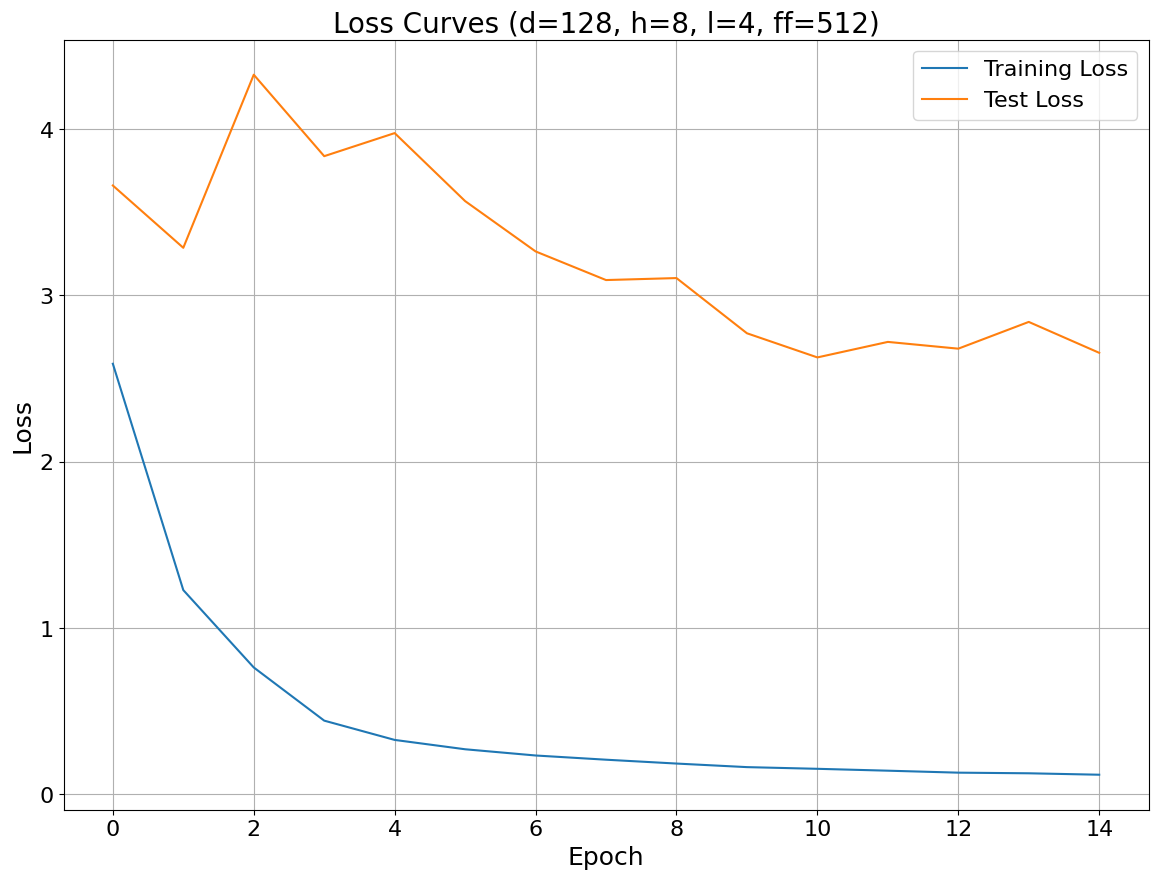

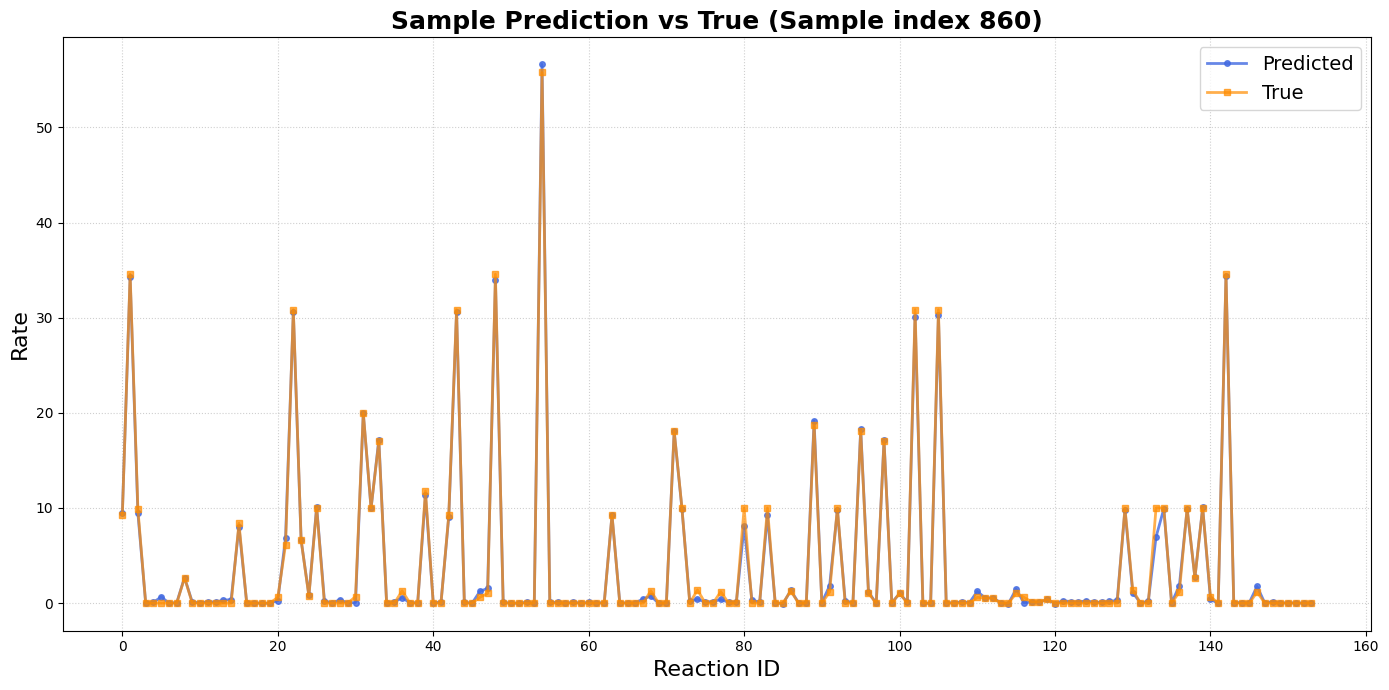

(6160, 154) (6160, 154)
y_pred_outputs.shape: (6160, 154) min/max: -1.5690098 77.11232
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.73029613 to 1.2341787


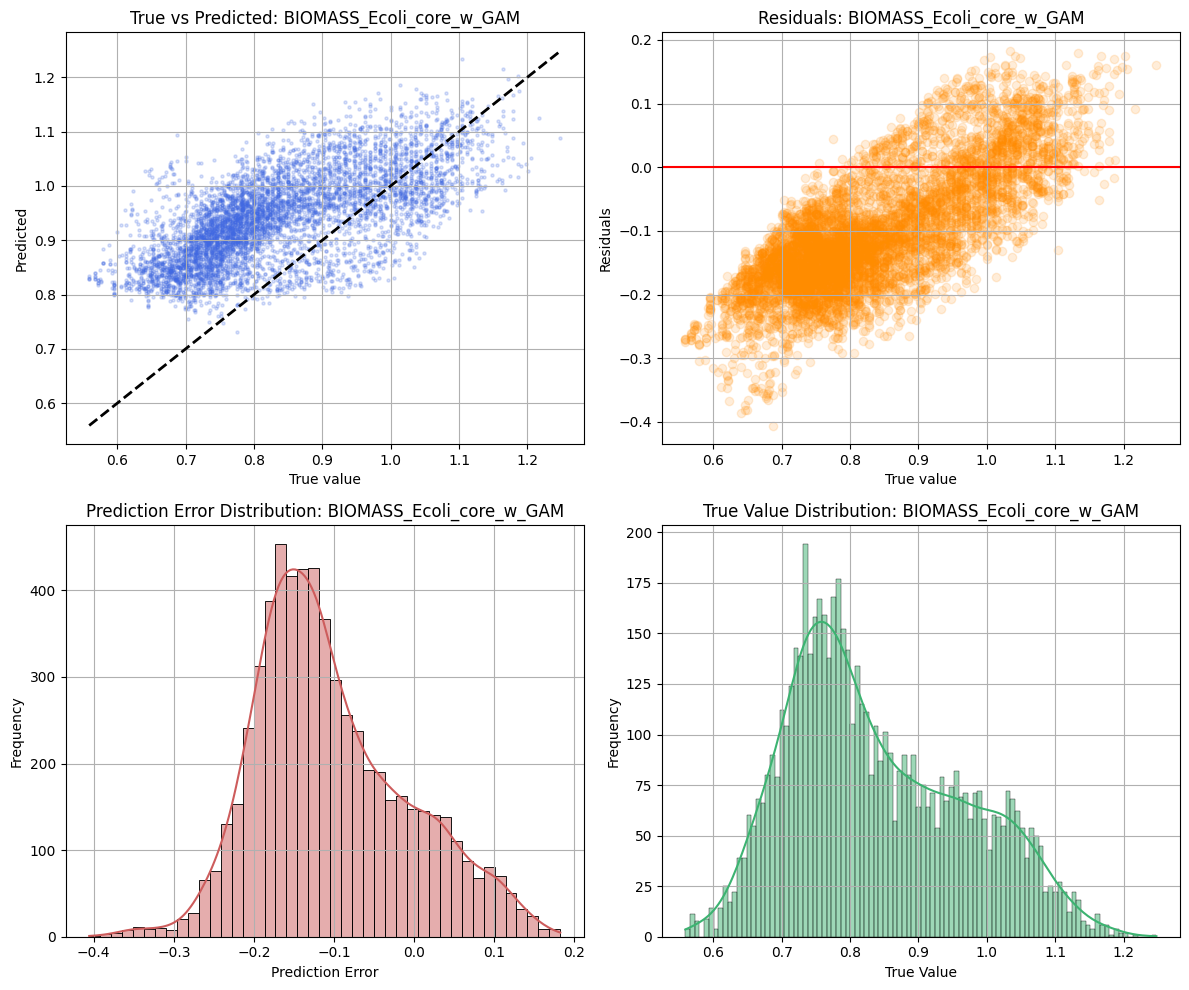

GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.19605231 to 3.5671024


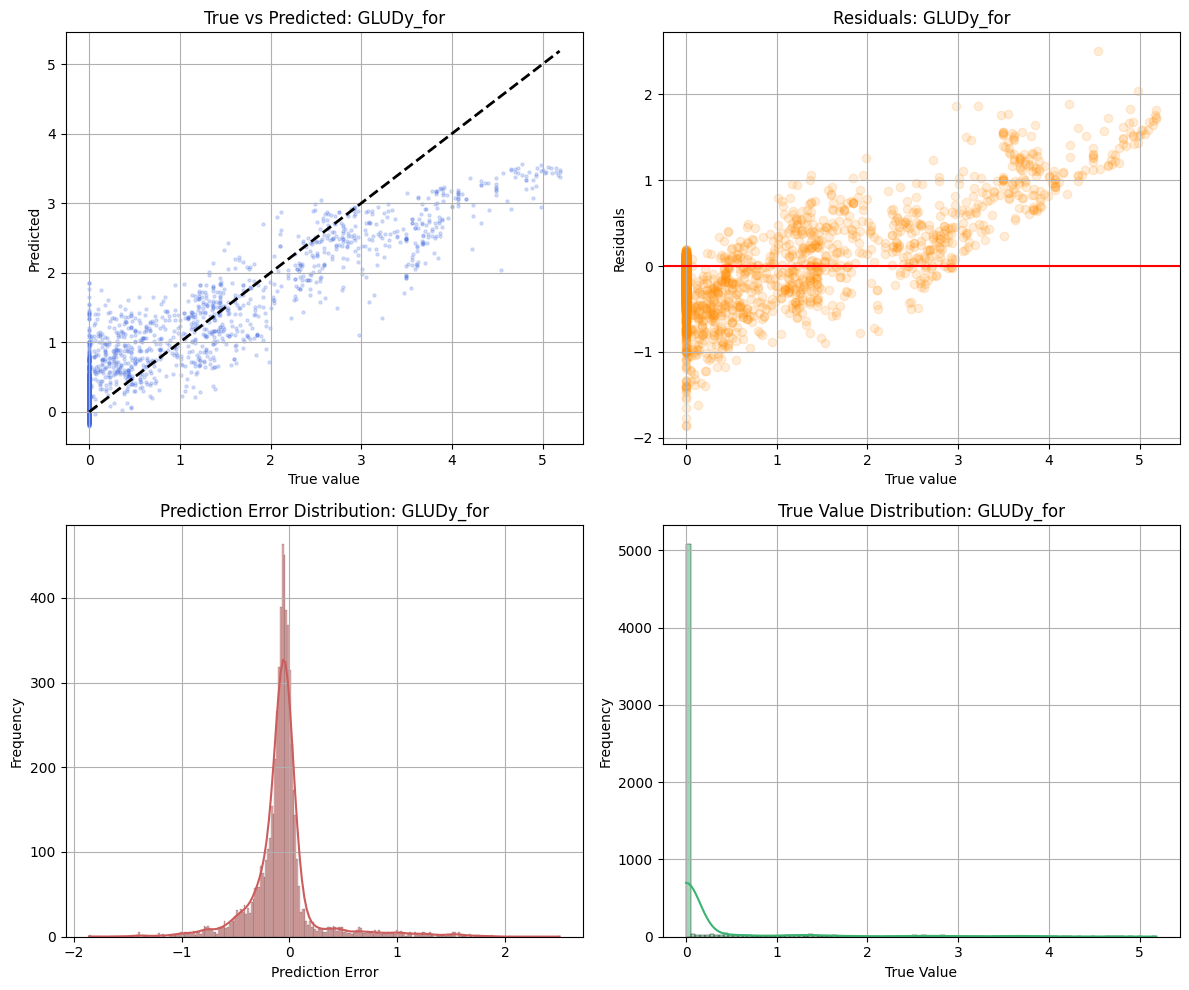

EX_h_e_o index in outputs: 54
y_true_outputs[:, idx] range: 0.0 to 86.397766
y_pred_outputs[:, _idx] range: -1.5690098 to 77.11232


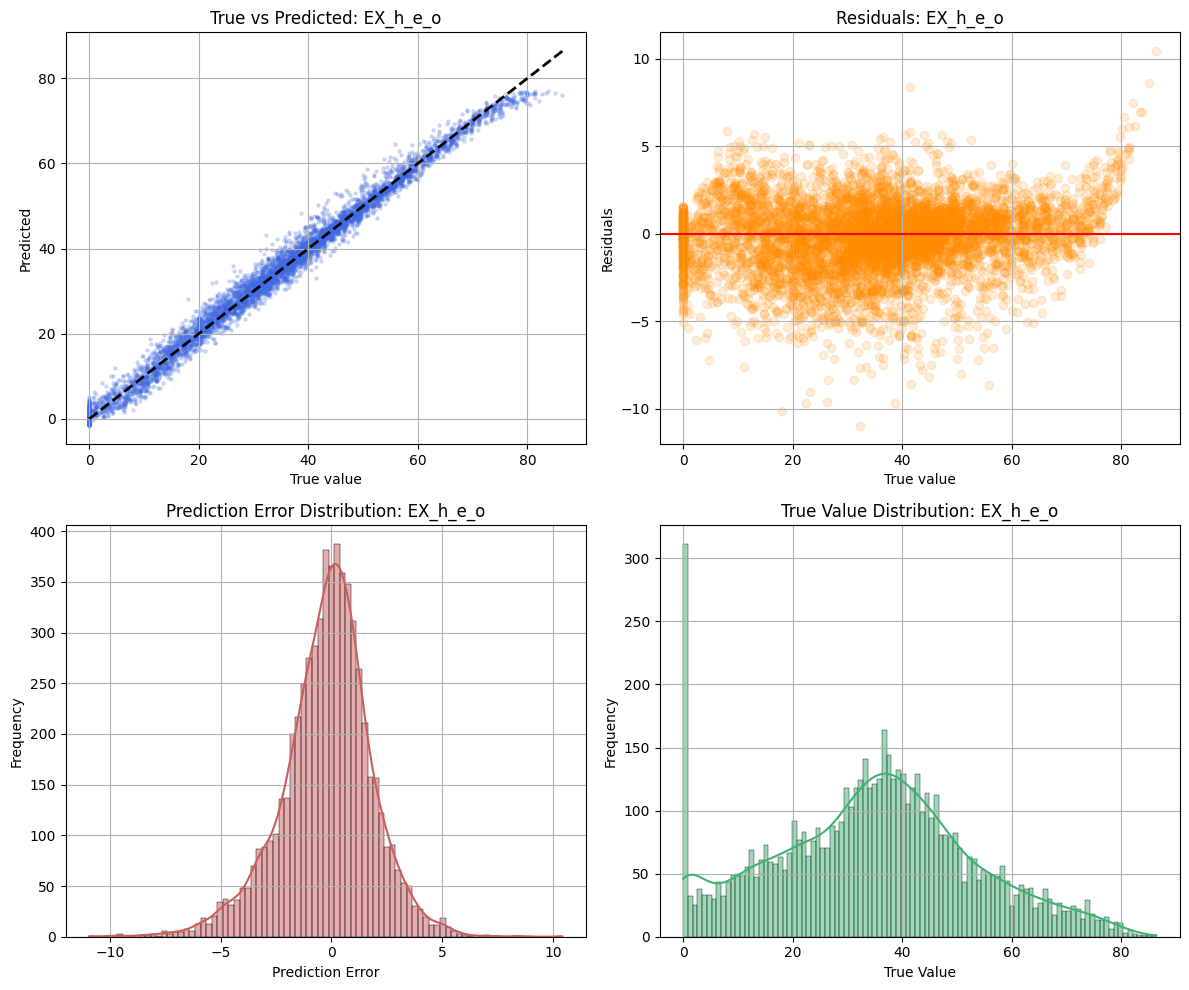

Number of parameters:
816940


In [54]:
model.to('mps')
plot_loss_curves(train_losses, test_losses, d_model=config['d_model'], n_heads=config['n_heads'], n_layers=config['n_layers'], d_ff=config['d_ff'],log_scale=False)

plot_prediction_sample(X_test, y_test, model)


plot_flux(model, X_test, y_test, output_cols, diagnostics_to_plot)

print('Number of parameters:')
print(sum( p.numel() for p in model.parameters() if p.requires_grad ))